# Part 1 - Text Autocomplete with LSTM

Character-level autoregressive text generation using a two-layer LSTM trained on Mary Shelley's *Frankenstein*.


## Dataset Download and Execution Instructions

Run this notebook from top to bottom in a Python environment with TensorFlow installed.

Datasets are downloaded automatically:

- *Frankenstein* is downloaded from Project Gutenberg through `tf.keras.utils.get_file`.
- The English-French dataset is downloaded from the ManyThings/Tatoeba Anki collection and limited to 10,000 sentence pairs.
- AG News is downloaded through `tensorflow_datasets`.

Recommended execution environment:

- Python 3.10 or newer.
- TensorFlow 2.15 or newer.
- A GPU is recommended for the full training configuration.

The first LSTM text generation model is intentionally trained for 32 epochs as required. On CPU this can take a long time.

In [29]:
# Global imports and reproducibility setup
import os
import re
import random
import string
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


## Shared Helper Functions

These utility functions keep plotting, text cleaning, and prediction display consistent across the three parts.

In [31]:
def plot_training_curves(history, metrics=("loss", "accuracy"), title_prefix="Model"):
    'Plot training and validation curves from a Keras History object.'
    history_df = pd.DataFrame(history.history)
    available_metrics = [m for m in metrics if m in history_df.columns]
    if not available_metrics:
        available_metrics = ["loss"]

    fig, axes = plt.subplots(1, len(available_metrics), figsize=(6 * len(available_metrics), 4))
    if len(available_metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, available_metrics):
        ax.plot(history_df[metric], label=f"train_{metric}")
        val_metric = f"val_{metric}"
        if val_metric in history_df:
            ax.plot(history_df[val_metric], label=val_metric)
        ax.set_title(f"{title_prefix}: {metric}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.legend()

    plt.tight_layout()
    plt.show()


def normalize_spaces(text):
    'Lowercase text and collapse repeated whitespace.'
    return re.sub(r"\s+", " ", text.lower()).strip()


def clean_sentence(text):
    'Basic sentence cleaning used for translation and classification examples.'
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z\u00C0-\u00FF?.!,;:'\- ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Part 1 - Text Autocomplete with LSTM

## Objective

The first model is an autoregressive character-level language model. Given a fixed-length sequence of characters, it predicts the next character. During generation, the predicted character is appended to the context and fed back into the model.

This is a useful educational setup because it exposes the complete sequence modeling pipeline: character encoding, sliding-window sample creation, recurrent modeling, and autoregressive decoding.

## 1.1 Text Preprocessing

The source text is downloaded from Project Gutenberg, converted to lowercase, and normalized by collapsing repeated whitespace. Gutenberg header/footer markers are removed when present so the model focuses on the novel text.

In [32]:
FRANKENSTEIN_URL = "https://www.gutenberg.org/files/84/84-0.txt"
frankenstein_path = keras.utils.get_file("frankenstein_gutenberg_84.txt", FRANKENSTEIN_URL)

raw_text = Path(frankenstein_path).read_text(encoding="utf-8")

start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK FRANKENSTEIN"
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK FRANKENSTEIN"

start_idx = raw_text.find(start_marker)
end_idx = raw_text.find(end_marker)
if start_idx != -1 and end_idx != -1:
    raw_text = raw_text[start_idx:end_idx]

text = normalize_spaces(raw_text)

print("Number of characters after cleaning:", len(text))
print("Preview:")
print(text[:600])

Number of characters after cleaning: 418379
Preview:
*** start of the project gutenberg ebook 84 *** frankenstein; or, the modern prometheus by mary wollstonecraft (godwin) shelley contents letter 1 letter 2 letter 3 letter 4 chapter 1 chapter 2 chapter 3 chapter 4 chapter 5 chapter 6 chapter 7 chapter 8 chapter 9 chapter 10 chapter 11 chapter 12 chapter 13 chapter 14 chapter 15 chapter 16 chapter 17 chapter 18 chapter 19 chapter 20 chapter 21 chapter 22 chapter 23 chapter 24 letter 1 _to mrs. saville, england._ st. petersburgh, dec. 11th, 17—. you will rejoice to hear that no disaster has accompanied the commencement of an enterprise which you 


## 1.2 Character Encoding

Each unique character becomes a vocabulary item. We create two dictionaries:

- `char_to_idx`: maps a character to an integer id.
- `idx_to_char`: maps an integer id back to a character.

The vocabulary size determines the width of the one-hot representation and the number of classes in the softmax output layer.

In [33]:
chars = sorted(set(text))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(chars)

print("Vocabulary size:", vocab_size)
print("Characters:")
print("".join(chars))

Vocabulary size: 60
Characters:
 !()*,-.0123456789:;?[]_abcdefghijklmnopqrstuvwxyzæèéêô—‘’“”


## 1.3 Sliding-Window Training Sample Generation

The model receives a sequence of `SEQ_LENGTH` characters and learns to predict the next character. A sliding window creates many overlapping training examples.

For memory efficiency, integer sequences are stored first. One-hot encoding is applied inside a `tf.data` pipeline before training, which still satisfies the one-hot input requirement while avoiding a very large dense array in RAM.

In [34]:
SEQ_LENGTH = 60
STEP = 3
BATCH_SIZE_CHAR = 256

sentences = []
next_chars = []

for i in range(0, len(text) - SEQ_LENGTH, STEP):
    sentences.append(text[i : i + SEQ_LENGTH])
    next_chars.append(text[i + SEQ_LENGTH])

x_char_int = np.zeros((len(sentences), SEQ_LENGTH), dtype=np.int32)
y_char_int = np.zeros((len(sentences),), dtype=np.int32)

for i, sentence in enumerate(sentences):
    x_char_int[i] = [char_to_idx[ch] for ch in sentence]
    y_char_int[i] = char_to_idx[next_chars[i]]

print("Number of training samples:", len(sentences))
print("Input integer tensor shape:", x_char_int.shape)
print("Target integer tensor shape:", y_char_int.shape)

validation_fraction = 0.1
num_val = int(len(x_char_int) * validation_fraction)
x_train_char, x_val_char = x_char_int[:-num_val], x_char_int[-num_val:]
y_train_char, y_val_char = y_char_int[:-num_val], y_char_int[-num_val:]


def one_hot_char_batch(x, y):
    x = tf.one_hot(x, depth=vocab_size)
    y = tf.one_hot(y, depth=vocab_size)
    return x, y


train_char_ds = (
    tf.data.Dataset.from_tensor_slices((x_train_char, y_train_char))
    .shuffle(20_000, seed=SEED)
    .batch(BATCH_SIZE_CHAR)
    .map(one_hot_char_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_char_ds = (
    tf.data.Dataset.from_tensor_slices((x_val_char, y_val_char))
    .batch(BATCH_SIZE_CHAR)
    .map(one_hot_char_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

Number of training samples: 139440
Input integer tensor shape: (139440, 60)
Target integer tensor shape: (139440,)


## 1.4 Model Architecture and Hyperparameters

The required model uses two LSTM layers. The first LSTM returns the full sequence so the second LSTM can process temporal features at every position. Dropout and recurrent dropout reduce overfitting.

Key hyperparameters:

- `SEQ_LENGTH = 60`: context length used to predict the next character.
- `BATCH_SIZE = 256`: stable gradient estimate while remaining practical on most GPUs.
- `EPOCHS = 32`: required full training duration.
- `DROPOUT = 0.2` and `RECURRENT_DROPOUT = 0.2`: regularization for input and recurrent connections.

In [35]:
char_model = keras.Sequential(
    [
        layers.Input(shape=(SEQ_LENGTH, vocab_size)),
        layers.LSTM(
            256,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2,
            name="lstm_1",
        ),
        layers.LSTM(
            256,
            dropout=0.2,
            recurrent_dropout=0.2,
            name="lstm_2",
        ),
        layers.Dense(vocab_size, activation="softmax", name="next_character_softmax"),
    ],
    name="frankenstein_char_lstm",
)

char_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

char_model.summary()

Model: "frankenstein_char_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 60, 256)             │         324,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ next_character_softmax (Dense)       │ (None, 60)                  │          15,420 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 865,340 (3.30 MB)

 Trainable params: 865,340 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

## 1.5 Training

The model is trained with a chronological validation split. This evaluates generalization on later parts of the novel rather than on randomly mixed fragments.

In [36]:
EPOCHS_CHAR = 32

char_callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_frankenstein_char_lstm.keras",
        monitor="val_loss",
        save_best_only=True,
        save_freq="epoch",
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    ),
]

char_history = char_model.fit(
    train_char_ds,
    validation_data=val_char_ds,
    epochs=EPOCHS_CHAR,
    callbacks=char_callbacks,
)

Epoch 1/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 192s 384ms/step - accuracy: 0.2341 - loss: 2.7191 - val_accuracy: 0.3080 - val_loss: 2.3529
Epoch 2/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 192s 390ms/step - accuracy: 0.3299 - loss: 2.2760 - val_accuracy: 0.3647 - val_loss: 2.1168
Epoch 3/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 190s 387ms/step - accuracy: 0.3749 - loss: 2.1018 - val_accuracy: 0.4094 - val_loss: 1.9760
Epoch 4/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 190s 388ms/step - accuracy: 0.4006 - loss: 2.0041 - val_accuracy: 0.4284 - val_loss: 1.9087
Epoch 5/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 190s 388ms/step - accuracy: 0.4196 - loss: 1.9314 - val_accuracy: 0.4437 - val_loss: 1.8509
Epoch 6/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 190s 387ms/step - accuracy: 0.4354 - loss: 1.8704 - val_accuracy: 0.4596 - val_loss: 1.7948
Epoch 7/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 190s 387ms/step - accuracy: 0.4493 - loss: 1.8206 - val_accuracy: 0.4657 - val_loss: 1.7568
Epoch 8/32
491/491 ━━━━━━━━━━━━━━━━━━━━ 191s 389ms/step - accuracy: 0.4616 -

## 1.6 Evaluation and Loss Visualization

Training and validation loss show whether the language model is learning useful next-character distributions and whether it is overfitting.

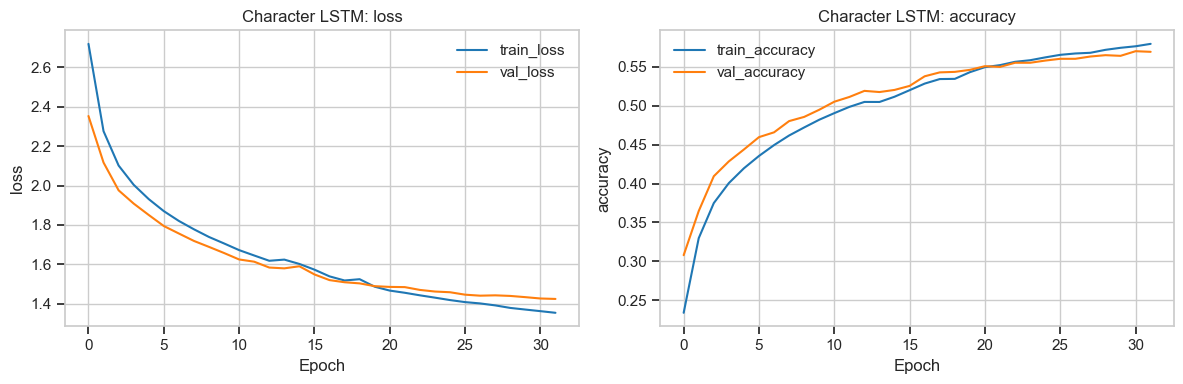

In [37]:
plot_training_curves(char_history, metrics=("loss", "accuracy"), title_prefix="Character LSTM")

## 1.7 Text Generation: Greedy Decoding and Beam Search

Greedy decoding chooses the most likely next character at every step. Beam search keeps multiple candidate continuations and often produces more coherent text because it considers sequence-level probability.

In [38]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

def prepare_prompt(prompt, seq_length=None):
    if seq_length is None:
        seq_length = 60
    prompt = normalize_spaces(prompt)
    prompt = "".join(ch for ch in prompt if ch in char_to_idx)
    if len(prompt) < seq_length:
        prompt = (" " * (seq_length - len(prompt))) + prompt
    return prompt[-seq_length:]


def predict_next_char_distribution(model, context):
    encoded = np.array([[char_to_idx.get(ch, char_to_idx[" "]) for ch in context]], dtype=np.int32)
    one_hot = tf.one_hot(encoded, depth=vocab_size)
    probs = model.predict(one_hot, verbose=0)[0]
    return probs


def generate_greedy(model, prompt, length=200):
    context = prepare_prompt(prompt)
    generated = prompt

    for _ in range(length):
        probs = predict_next_char_distribution(model, context)
        next_idx = int(np.argmax(probs))
        next_char = idx_to_char[next_idx]
        generated += next_char
        context = (context + next_char)[-60:]

    return generated


def generate_beam_search(model, prompt, length=200, beam_width=3):
    initial_context = prepare_prompt(prompt)
    beams = [(initial_context, prompt, 0.0)]

    for _ in range(length):
        candidates = []
        for context, generated, score in beams:
            probs = predict_next_char_distribution(model, context)
            top_indices = np.argsort(probs)[-beam_width:]
            for idx in top_indices:
                ch = idx_to_char[int(idx)]
                new_context = (context + ch)[-60:]
                new_score = score + np.log(float(probs[idx]) + 1e-12)
                candidates.append((new_context, generated + ch, new_score))
        beams = sorted(candidates, key=lambda item: item[2], reverse=True)[:beam_width]

    return beams[0][1]


char_model = keras.models.load_model("best_frankenstein_char_lstm.keras")

prompt = "it was on a dreary "
print("Prompt:", prompt)
print("\nGreedy generation:\n")
print(generate_greedy(char_model, prompt, length=250))
print("\nBeam-search generation:\n")
print(generate_beam_search(char_model, prompt, length=250, beam_width=3))

Prompt: it was on a dreary 

Greedy generation:

it was on a dreary  and the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the sun of the

Beam-search generation:

it was on a dreary  and that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that i had been that 


## Part 1 Notes

Greedy decoding is faster and deterministic, but it may repeat common character patterns. Beam search is slower because it evaluates several candidate continuations, but it can produce text with better local consistency. Character-level generation usually needs many epochs and large text corpora to produce fluent paragraphs.

# Technical Report - Part 1

## Architecture Choices

This model uses a character-level autoregressive LSTM. A two-layer LSTM stack models temporal dependencies over fixed-length character windows. The first LSTM returns sequences so the second LSTM can process the full temporal representation. The final dense softmax layer predicts the next character.

## Hyperparameters and Training

- Sequence length: 60 characters
- Batch size: 256
- LSTM layers: 2
- LSTM units: 256 per layer
- Dropout: 0.2
- Recurrent dropout: 0.2
- Epochs: 32
- Optimizer: Adam
- Loss: categorical cross-entropy

## Evaluation

Evaluation is performed through training/validation loss curves, accuracy curves, and qualitative generated text examples using greedy decoding and beam search.

## Limitations and Improvements

Character-level models learn spelling and style slowly and may struggle with long-range meaning. Improvements include temperature sampling, larger training corpora, more LSTM units, pretrained language models, or Transformer-based generation.

## Conclusion

The notebook demonstrates the full autoregressive text generation workflow: preprocessing, character encoding, sliding-window training, LSTM modeling, evaluation, and text generation.

# Requirements

```text
tensorflow>=2.15
tensorflow-datasets>=4.9
numpy>=1.24
pandas>=2.0
matplotlib>=3.7
seaborn>=0.13
scikit-learn>=1.3
jupyter>=1.0
```
